# Heart Disease Risk Classifier — Phase 1: EDA
Cleveland Heart Disease Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading Data
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [3]:
# Checking names of columns
COL_NAMES = ["age", "sex", "cp", "trestbps", "chol", "fbs",
             "restecg", "thalach", "exang", "oldpeak",
             "slope", "ca", "thal", "target"]
 
# Trying standard Kaggle CSV first, to check that the data is accurate
try:
    df = pd.read_csv("heart.csv")
    if df.shape[1] != 14:
        raise ValueError("Unexpected column count")
except Exception:
    df = pd.read_csv("heart.csv", header=None, names=COL_NAMES)
 
# Normalise target: UCI uses 0=no disease, 1-4=disease → collapse to binary so as to just have two categories
if df["target"].max() > 1:
    df["target"] = (df["target"] > 0).astype(int)
 
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head().to_string())
print(f"\nData types:\n{df.dtypes.to_string()}")
 

Shape  : (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
0   63    1   0       145   233    1        2      150      0      2.3      2   0     2       0
1   67    1   3       160   286    0        2      108      1      1.5      1   3     1       1
2   67    1   3       120   229    0        2      129      1      2.6      1   2     3       1
3   37    1   2       130   250    0        0      187      0      3.5      2   0     1       0
4   41    0   1       130   204    0        2      172      0      1.4      0   0     1       0

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal 

# CHECKING FOR IMBALANCE IN CLASSES


Class balance:
  No disease (0): 164  (54.1%)
  Disease    (1): 139  (45.9%)

Mild imbalance — no SMOTE needed, but report F1 not just accuracy.


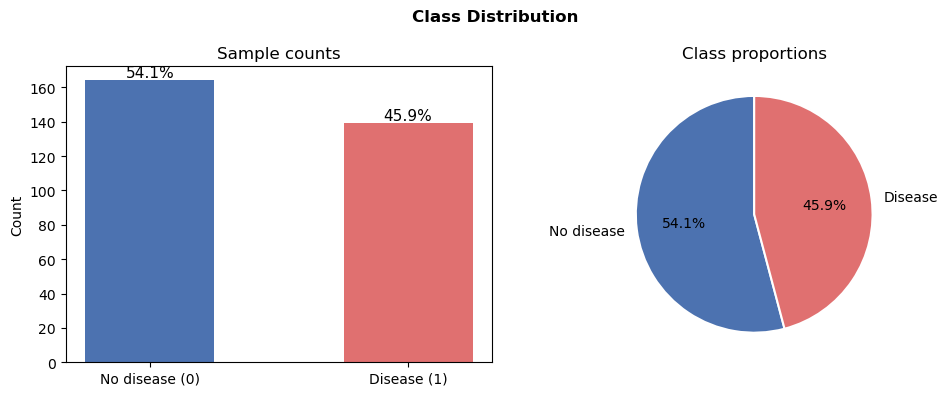

In [4]:

counts = df["target"].value_counts().sort_index()
pcts   = df["target"].value_counts(normalize=True).sort_index() * 100
 
print(f"\nClass balance:")
print(f"  No disease (0): {counts[0]:>3}  ({pcts[0]:.1f}%)")
print(f"  Disease    (1): {counts[1]:>3}  ({pcts[1]:.1f}%)")
print(f"\nMild imbalance — no SMOTE needed, but report F1 not just accuracy.")
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Class Distribution", fontweight="bold")
 
# Bar chart
ax = axes[0]
bars = ax.bar(["No disease (0)", "Disease (1)"],
              counts.values,
              color=["#4C72B0", "#E07070"], width=0.5)
ax.set_ylabel("Count")
ax.set_title("Sample counts")
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{pct:.1f}%", ha="center", fontsize=11)
 
# Pie chart
ax2 = axes[1]
ax2.pie(counts.values, labels=["No disease", "Disease"],
        colors=["#4C72B0", "#E07070"],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax2.set_title("Class proportions")
ax2.grid(False)
 
plt.tight_layout()
plt.savefig("phase1_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

#  FEATURE DISTRIBUTIONS — VIOLIN PLOTS BY TARGET CLASS

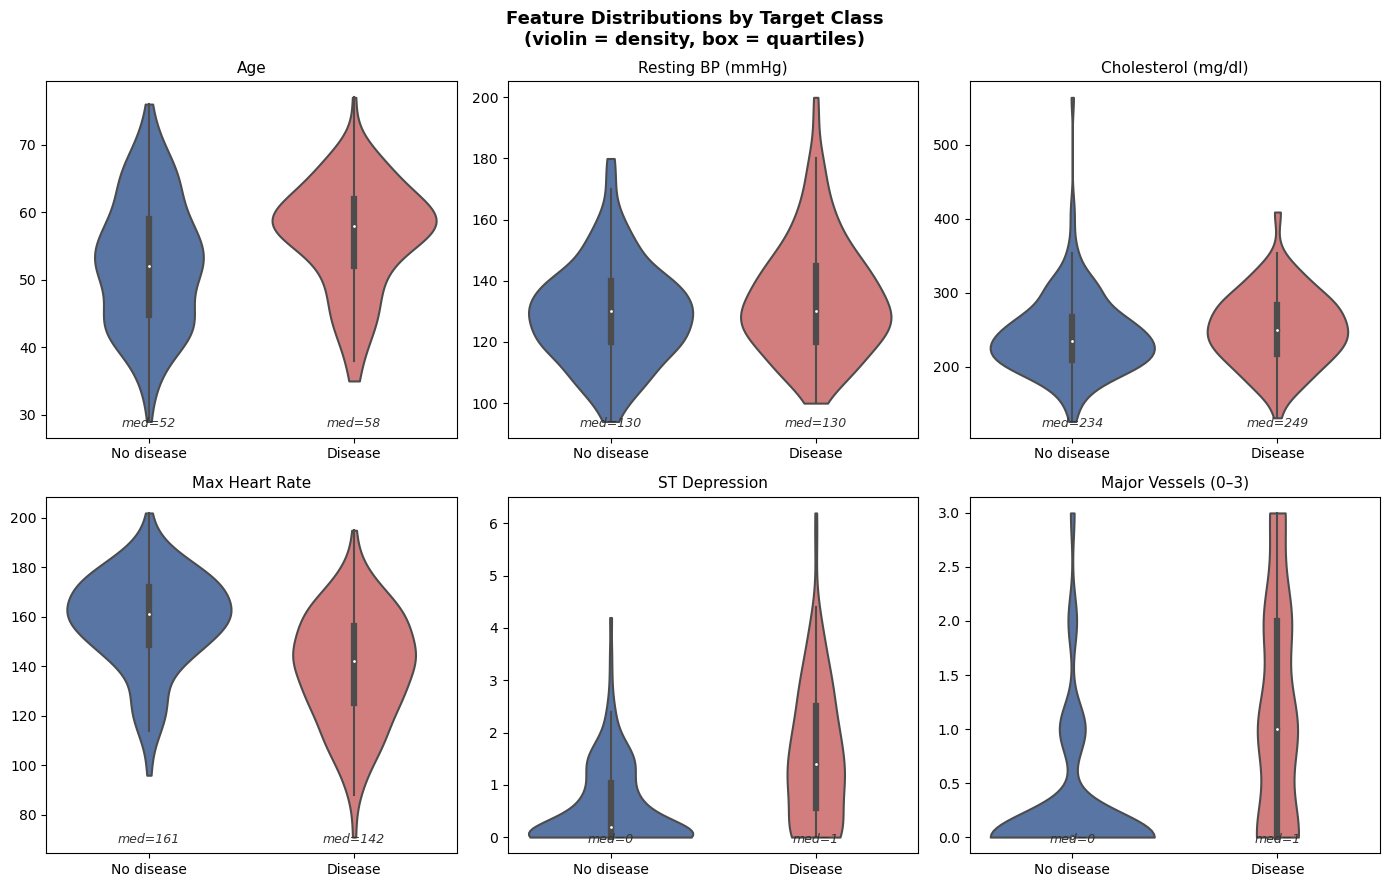

In [5]:
# Human-readable labels
LABELS = {
    "age"     : "Age",
    "trestbps": "Resting BP (mmHg)",
    "chol"    : "Cholesterol (mg/dl)",
    "thalach" : "Max Heart Rate",
    "oldpeak" : "ST Depression",
    "ca"      : "Major Vessels (0–3)",
}
 
NUMERIC_FEATS = list(LABELS.keys())
 
df["Class"] = df["target"].map({0: "No disease", 1: "Disease"})
 
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Feature Distributions by Target Class\n(violin = density, box = quartiles)",
             fontweight="bold", fontsize=13)
axes = axes.flatten()
 
for i, feat in enumerate(NUMERIC_FEATS):
    ax = axes[i]
    sns.violinplot(data=df, x="Class", y=feat,
                   palette={"No disease": "#4C72B0", "Disease": "#E07070"},
                   inner="box", cut=0, ax=ax)
    ax.set_title(LABELS[feat], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
 
    # Annotate medians
    for j, cls in enumerate(["No disease", "Disease"]):
        med = df.loc[df["Class"] == cls, feat].median()
        ax.text(j, ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03,
                f"med={med:.0f}", ha="center", fontsize=9,
                color="#333", style="italic")
 
plt.tight_layout()
plt.savefig("phase1_violin_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Print key separating features
print("\nMedian comparison — key features:")
print(f"{'Feature':<22} {'No disease':>12} {'Disease':>10} {'Separation':>12}")
print("-" * 58)
for feat in NUMERIC_FEATS:
    m0 = df.loc[df["target"] == 0, feat].median()
    m1 = df.loc[df["target"] == 1, feat].median()
    diff_pct = abs(m1 - m0) / max(abs(m0), 0.01) * 100
    marker = "  ← strong" if diff_pct > 20 else ""
    print(f"{LABELS[feat]:<22} {m0:>12.1f} {m1:>10.1f} {diff_pct:>10.1f}%{marker}")


Median comparison — key features:
Feature                  No disease    Disease   Separation
----------------------------------------------------------
Age                            52.0       58.0       11.5%
Resting BP (mmHg)             130.0      130.0        0.0%
Cholesterol (mg/dl)           234.5      249.0        6.2%
Max Heart Rate                161.0      142.0       11.8%
ST Depression                   0.2        1.4      600.0%  ← strong
Major Vessels (0–3)             0.0        1.0    10000.0%  ← strong


c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


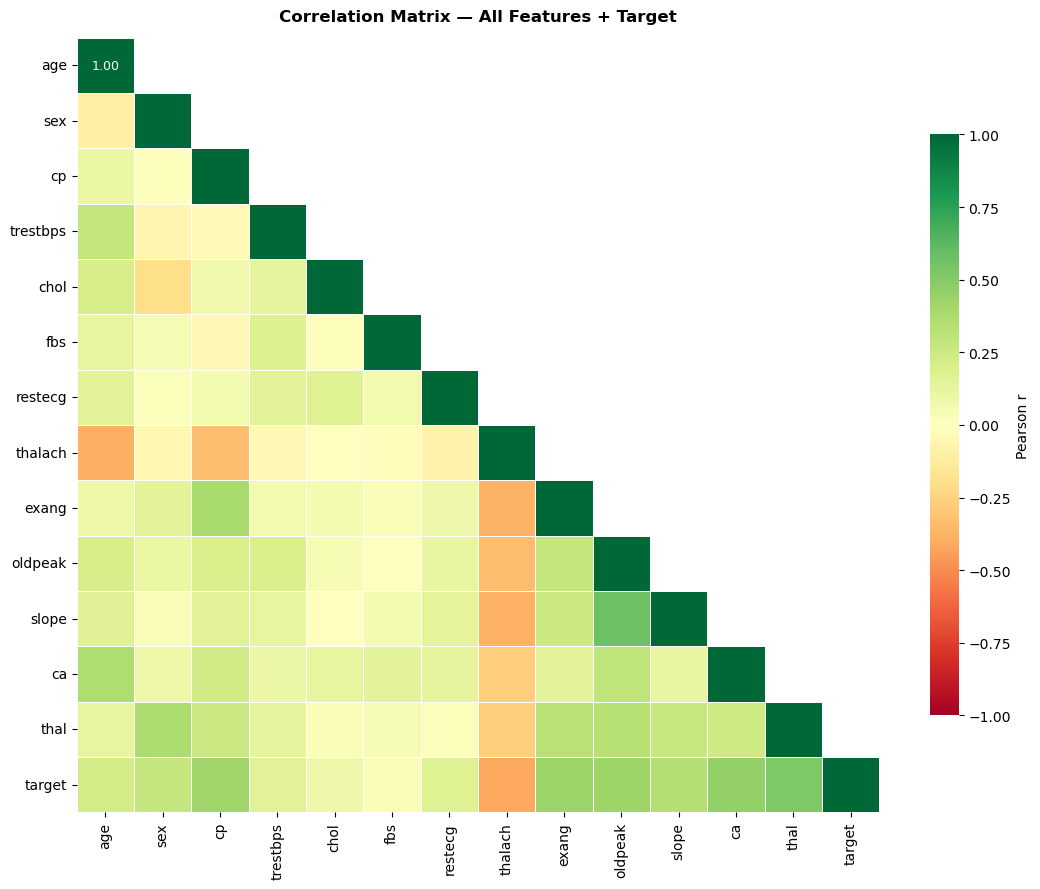


Features most correlated with target (absolute r):
thal       0.516
ca         0.460
exang      0.432
oldpeak    0.425
thalach    0.417
cp         0.414
slope      0.339
sex        0.277


In [7]:
# CORRELATION HEATMAP

 
corr_df  = df.drop(columns=["Class"])
corr_mat = corr_df.corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
 
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white",
            annot_kws={"size": 9}, ax=ax,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})
ax.set_title("Correlation Matrix — All Features + Target",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("phase1_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Top correlations with target
target_corr = (corr_mat["target"]
               .drop("target")
               .abs()
               .sort_values(ascending=False))
 
print("\nFeatures most correlated with target (absolute r):")
print(target_corr.round(3).head(8).to_string())
 

In [9]:
print("\n" + "=" * 55)
print("PHASE 1 SUMMARY")
print("=" * 55)
print(f"  Clean rows       : {len(df)}")
print(f"  Features         : {df.shape[1] - 2}  (excl. target + Class label)")
print(f"  Class balance    : {pcts[0]:.1f}% / {pcts[1]:.1f}%  (no disease / disease)")
print(f"  Top separator    : {target_corr.index[0]}  (r={corr_mat['target'][target_corr.index[0]]:.3f})")
 
print("\nSaved:")
print("  phase1_class_balance.png")
print("  phase1_violin_plots.png")
print("  phase1_correlation_heatmap.png")
print("\nNext: Phase 2 & 3 — Preprocessing pipeline + model comparison")


PHASE 1 SUMMARY
  Clean rows       : 303
  Features         : 13  (excl. target + Class label)
  Class balance    : 54.1% / 45.9%  (no disease / disease)
  Top separator    : thal  (r=0.516)

Saved:
  phase1_class_balance.png
  phase1_violin_plots.png
  phase1_correlation_heatmap.png

Next: Phase 2 & 3 — Preprocessing pipeline + model comparison
